# Unit10 Example 03 - 固體球體之急速冷卻 (Quench Cooling of a Hot Solid Sphere)

本 Notebook 以**固體熱球體急速投入冷水浴**為範例，示範如何使用 `py-pde` 套件求解球座標非穩態熱傳 PDE，並探討**變數代換技巧**（令 $v = r(T - T_\infty)$ ）將球座標方程式轉換為等效一維平板方程式。

## 目標
- 建立球座標非穩態熱傳數學模型，理解中心對稱 Neumann 條件與表面 Robin 條件
- 應用變數代換 $v = \xi\theta^*$ 消除球座標奇異性，轉為 CartesianGrid 求解
- 使用 `py-pde` 的 `SphericalSymGrid` 直接求解球座標問題
- 計算 Fourier 級數精確解析解作為驗證基準
- 分析 Biot number 對球體冷卻速率的影響，並與 Heisler chart 比對

**參考來源：** Constantinides and Mostoufi (1999)，教材第五章範例 5-3-3

---
### 0. 環境設定

In [2]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit10_Example_03'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit10'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit10
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_03
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_03\figs


---
### 1. 載入套件

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy
from scipy.optimize import brentq
import warnings
warnings.filterwarnings('ignore')

# ---------- 嘗試載入 py-pde ----------
try:
    import pde
    PDE_AVAILABLE = True
    print(f"✓ py-pde 版本: {pde.__version__}")
except ImportError:
    PDE_AVAILABLE = False
    print("⚠️ py-pde 未安裝，將僅使用 Method of Lines (MoL) 求解")
    print("  安裝方式: pip install py-pde")

# ---------- 繪圖樣式設定 ----------
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'lines.linewidth': 1.8,
    'axes.unicode_minus': False,
})
print("✓ 套件載入完成")
print(f"  numpy      版本: {np.__version__}")
print(f"  scipy      版本: {scipy.__version__}")
print(f"  matplotlib 版本: {matplotlib.__version__}")


✓ py-pde 版本: 0.51.0
✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. 問題定義與參數設定

**問題：** 初溫均勻 $T_i = 200\,°\text{C}$ 之固體球體（半徑 $R = 0.05\,\text{m}$ ），在 $t=0$ 時投入 $T_\infty = 20\,°\text{C}$ 的冷水浴，表面對流係數為 $h$ 。

**無因次化：** $\theta^* = (T-T_\infty)/(T_i-T_\infty)$ ，$\xi = r/R$ ，$Fo = \alpha t/R^2$

**統御方程式：** $\partial\theta^*/\partial Fo = (1/\xi^2)\,\partial_\xi(\xi^2\,\partial_\xi\theta^*)$

**邊界條件：** 球心 $\partial\theta^*/\partial\xi\big|_0 = 0$ （對稱）；球面 $-\partial\theta^*/\partial\xi\big|_1 = Bi\cdot\theta^*\big|_1$ （Robin）


In [4]:
# =============================================
# 物理參數設定
# =============================================
R     = 0.05    # 球體半徑 [m]
k     = 20.0    # 熱傳導係數 [W/(m·°C)]
rho   = 7800.0  # 密度 [kg/m³]
Cp    = 500.0   # 熱容量 [J/(kg·°C)]
alpha = k / (rho * Cp)  # 熱擴散率 [m²/s]
T_i   = 200.0   # 初始溫度 [°C]
T_inf = 20.0    # 冷卻液溫度 [°C]
dT    = T_i - T_inf  # 溫差 [°C]

# 三種 Biot number 案例 (h = Bi * k / R)
Bi_cases = {'Case A (Bi=0.1)': 0.1,
            'Case B (Bi=1.0)': 1.0,
            'Case C (Bi=10.0)': 10.0}

# 無因次模擬設定
Fo_max = 3.0    # 最大 Fourier number
t_max  = Fo_max * R**2 / alpha  # 對應物理時間 [s]

# 網格設定
N       = 60    # 徑向節點數
dFo_s   = 0.05  # 儲存時間間隔 (Fo 單位)

# 輸出參數摘要
print("=" * 54)
print("  問題參數摘要")
print("=" * 54)
print(f"  球體半徑   R     = {R:.3f} m")
print(f"  熱傳導係數 k     = {k:.1f} W/(m·°C)")
print(f"  密度       ρ     = {rho:.0f} kg/m³")
print(f"  熱容量     Cp    = {Cp:.1f} J/(kg·°C)")
print(f"  熱擴散率   α     = {alpha:.3e} m²/s")
print(f"  初始溫度   T_i   = {T_i:.1f} °C")
print(f"  冷卻液溫度 T_inf = {T_inf:.1f} °C")
print(f"  最大 Fourier number Fo_max = {Fo_max:.1f}")
print(f"  對應物理時間 t_max = {t_max:.2f} s")
print()
print("  --- Biot number 案例 ---")
for name, Bi in Bi_cases.items():
    h = Bi * k / R
    print(f"  {name}: h={h:.1f} W/(m²·°C)")

  問題參數摘要
  球體半徑   R     = 0.050 m
  熱傳導係數 k     = 20.0 W/(m·°C)
  密度       ρ     = 7800 kg/m³
  熱容量     Cp    = 500.0 J/(kg·°C)
  熱擴散率   α     = 5.128e-06 m²/s
  初始溫度   T_i   = 200.0 °C
  冷卻液溫度 T_inf = 20.0 °C
  最大 Fourier number Fo_max = 3.0
  對應物理時間 t_max = 1462.50 s

  --- Biot number 案例 ---
  Case A (Bi=0.1): h=40.0 W/(m²·°C)
  Case B (Bi=1.0): h=400.0 W/(m²·°C)
  Case C (Bi=10.0): h=4000.0 W/(m²·°C)


---
### 3. 解析解：Fourier 級數精確解

球座標熱傳無因次精確解：

$$
\theta^*(\xi, Fo) = \sum_{n=1}^{\infty} C_n \frac{\sin(\lambda_n \xi)}{\lambda_n \xi} \exp(-\lambda_n^2 Fo)
$$

本徵值 $\lambda_n$ 為超越方程式 $1 - \lambda_n\cot(\lambda_n) = Bi$ 的正根，係數 $C_n = 4[\sin(\lambda_n) - \lambda_n\cos(\lambda_n)] / [2\lambda_n - \sin(2\lambda_n)]$

In [5]:
def get_eigenvalues(Bi, n_eig=30):
    """求解超越方程式 1 - lambda*cot(lambda) = Bi 的前 n_eig 個正根"""
    lambdas = []
    for n in range(1, n_eig + 1):
        # 每個根在 ((n-1)*pi, n*pi) 之間（避開奇點）
        a = (n - 1) * np.pi + 1e-8
        b = n * np.pi - 1e-8
        # 超越方程式: 1 - lambda*cos(lambda)/sin(lambda) - Bi = 0
        def f(lam): return 1.0 - lam / np.tan(lam) - Bi
        try:
            root = brentq(f, a + 0.01, b - 0.01)
            lambdas.append(root)
        except ValueError:
            break
    return np.array(lambdas)


def analytical_sphere(xi_arr, Fo_arr, Bi, n_eig=50):
    """
    Fourier 級數精確解：球座標非穩態熱傳無因次溫度
    回傳: theta_arr 形狀 (len(Fo_arr), len(xi_arr))
    """
    lambdas = get_eigenvalues(Bi, n_eig)
    Cn = 4.0 * (np.sin(lambdas) - lambdas * np.cos(lambdas)) / \
         (2.0 * lambdas - np.sin(2.0 * lambdas))

    xi_arr  = np.asarray(xi_arr)
    Fo_arr  = np.asarray(Fo_arr)
    theta   = np.zeros((len(Fo_arr), len(xi_arr)))

    for n, (lam, cn) in enumerate(zip(lambdas, Cn)):
        exp_term = np.exp(-lam**2 * Fo_arr)          # (n_Fo,)
        # sin(lambda*xi) / (lambda*xi), with limit 1 at xi=0
        sinc_term = np.ones_like(xi_arr)
        mask = xi_arr > 1e-10
        sinc_term[mask] = np.sin(lam * xi_arr[mask]) / (lam * xi_arr[mask])
        # outer product
        theta += cn * np.outer(exp_term, sinc_term)

    return theta


# ---- 驗證：Case B (Bi=1.0) 的解析解 ----
Bi_test  = 1.0
lam_test = get_eigenvalues(Bi_test, 5)
print(f"--- Case B (Bi={Bi_test}) 前 5 個本徵值 ---")
for i, lam in enumerate(lam_test):
    print(f"  λ{i+1} = {lam:.4f}")

xi_test  = np.array([0.0, 0.5, 1.0])
Fo_test  = np.array([0.5, 1.0, 2.0])
th_test  = analytical_sphere(xi_test, Fo_test, Bi_test)
print(f"\n解析解 θ*(ξ=0, Fo=1.0) = {th_test[1, 0]:.4f}")
print(f"解析解 θ*(ξ=1, Fo=1.0) = {th_test[1, 2]:.4f}")

--- Case B (Bi=1.0) 前 5 個本徵值 ---
  λ1 = 1.5708
  λ2 = 4.7124
  λ3 = 7.8540
  λ4 = 10.9956
  λ5 = 14.1372

解析解 θ*(ξ=0, Fo=1.0) = 0.1080
解析解 θ*(ξ=1, Fo=1.0) = 0.0687


---
### 4. 方法一：`py-pde` SphericalSymGrid 直接求解

對三種 Biot number 分別以 `SphericalSymGrid` 在球座標系統中求解無因次熱傳方程式。

> **注意：** `py-pde` 0.51+ 中球座標網格為 `SphericalSymGrid`，球心 ( $\xi=0$ ) 對稱條件自動處理。球面 Robin BC 格式：`{"mixed": factor}` 代表 $\partial u / \partial n + \text{factor} \times u = 0$ （ $n$ 為外法方向），由於物理 BC 為 $\partial\theta^*/\partial\xi + Bi\cdot\theta^* = 0$ ，故使用 `{"mixed": +Bi}`（正值）。


In [8]:
results_sph = {}   # 儲存各 Bi 的 SphericalGrid 求解結果

if PDE_AVAILABLE:
    for case_name, Bi in Bi_cases.items():
        print(f"求解 {case_name} ...")

        # ---- 建立無因次球座標網格 ξ ∈ (0, 1] ----
        # py-pde 0.51+ 使用 SphericalSymGrid
        grid_sph = pde.SphericalSymGrid(1.0, N)
        xi_sph   = grid_sph.axes_coords[0]

        # ---- 初始場 θ*(ξ, 0) = 1 ----
        state_sph = pde.ScalarField(grid_sph, data=1.0)

        # ---- 邊界條件 ----
        # SphericalSymGrid 球心 (ξ=0) 自動處理對稱 Neumann 邊界
        # 球面 (ξ=1): Robin BC: ∂θ*/∂ξ + Bi*θ* = 0  =>  {"mixed": +Bi}
        bc_sph = {"mixed": Bi}

        # ---- 無因次擴散 PDE (擴散率=1，以 Fo 為時間) ----
        eq_sph = pde.DiffusionPDE(diffusivity=1.0, bc=bc_sph)

        # ---- 執行求解，儲存中間結果 ----
        storage_sph = pde.MemoryStorage()
        eq_sph.solve(state_sph, t_range=Fo_max, dt=1e-3,
                     tracker=[storage_sph.tracker(dFo_s)],
                     adaptive=True)

        # 提取結果
        theta_sph = np.array([f.data for f in storage_sph])  # (n_Fo, N)
        Fo_sph    = np.array(storage_sph.times)

        results_sph[case_name] = {
            'Bi': Bi, 'xi': xi_sph,
            'Fo': Fo_sph, 'theta': theta_sph
        }
        print(f"  ✓ 完成：節點數={N}, 時間點={len(Fo_sph)}, "
              f"最終球心 θ*={theta_sph[-1, 0]:.4f}, "
              f"球面 θ*={theta_sph[-1, -1]:.4f}")
else:
    print("⚠️ py-pde 未安裝，跳過 SphericalGrid 求解")


求解 Case A (Bi=0.1) ...
  ✓ 完成：節點數=60, 時間點=61, 最終球心 θ*=0.4262, 球面 θ*=0.4059
求解 Case B (Bi=1.0) ...
  ✓ 完成：節點數=60, 時間點=61, 最終球心 θ*=0.0008, 球面 θ*=0.0005
求解 Case C (Bi=10.0) ...
  ✓ 完成：節點數=60, 時間點=61, 最終球心 θ*=-0.0000, 球面 θ*=0.0000


---
### 5. 方法二：`py-pde` CartesianGrid 求解（變數代換 $v = \xi\theta^*$ ）

**轉換後的問題：**
- 統御方程式： $\partial v / \partial Fo = \partial^2 v / \partial\xi^2$
- 左端 $\xi = 0$ ：Dirichlet， $v = 0$
- 右端 $\xi = 1$ ：Robin， $\partial v/\partial\xi + (Bi-1)\,v = 0$ ，即 `{"mixed": +(Bi-1)}`
- 初始條件： $v(\xi, 0) = \xi$

求解後以 $\theta^* = v/\xi$ 還原（ $\xi = 0$ 的格點中心位於 $\Delta\xi/2 > 0$ ，不存在除以零問題）。


In [9]:
results_cart = {}  # 儲存各 Bi 的 CartesianGrid (v 代換) 求解結果

if PDE_AVAILABLE:
    for case_name, Bi in Bi_cases.items():
        print(f"求解 {case_name} (CartesianGrid, v=ξθ*) ...")

        # ---- 建立 1D Cartesian 網格 ξ ∈ [0, 1] ----
        grid_cart = pde.CartesianGrid([(0, 1)], N, periodic=False)
        xi_cart   = grid_cart.axes_coords[0]   # cell-centered, xi[0] = 0.5/N > 0

        # ---- 初始場 v(ξ, 0) = ξ ----
        v_init = pde.ScalarField(grid_cart, data=xi_cart.copy())

        # ---- 邊界條件 ----
        # 左端 ξ=0: Dirichlet v=0
        # 右端 ξ=1: Robin ∂v/∂ξ + (Bi-1)*v = 0 → {"mixed": +(Bi-1)}
        bc_cart = [{"value": 0.0}, {"mixed": (Bi - 1.0)}]

        # ---- 建立 PDE ----
        eq_cart = pde.DiffusionPDE(diffusivity=1.0, bc=bc_cart)

        # ---- 求解 ----
        storage_cart = pde.MemoryStorage()
        eq_cart.solve(v_init, t_range=Fo_max, dt=1e-3,
                      tracker=[storage_cart.tracker(dFo_s)],
                      adaptive=True)

        # 提取並還原 θ* = v / ξ
        v_mat     = np.array([f.data for f in storage_cart])  # (n_Fo, N)
        Fo_cart   = np.array(storage_cart.times)
        theta_cart= v_mat / xi_cart[np.newaxis, :]  # broadcast 除以 ξ

        results_cart[case_name] = {
            'Bi': Bi, 'xi': xi_cart,
            'Fo': Fo_cart, 'theta': theta_cart, 'v': v_mat
        }
        print(f"  ✓ 完成：最終球心 θ*={theta_cart[-1, 0]:.4f}, "
              f"球面 θ*={theta_cart[-1, -1]:.4f}")
else:
    print("⚠️ py-pde 未安裝，跳過 CartesianGrid 求解")


求解 Case A (Bi=0.1) (CartesianGrid, v=ξθ*) ...
  ✓ 完成：最終球心 θ*=0.4193, 球面 θ*=0.4059
求解 Case B (Bi=1.0) (CartesianGrid, v=ξθ*) ...
  ✓ 完成：最終球心 θ*=0.0008, 球面 θ*=0.0005
求解 Case C (Bi=10.0) (CartesianGrid, v=ξθ*) ...
  ✓ 完成：最終球心 θ*=0.0002, 球面 θ*=-0.0000


---
### 6. 誤差分析與 Heisler Chart 驗證

比較數值解（SphericalGrid 與 CartesianGrid）與精確 Fourier 級數解析解的誤差，並針對各 Biot number 在特定 Fourier number 下進行 Heisler chart 驗證。

In [10]:
# =====================================================================
# 以解析解為基準，計算 Fo=1.0 時各案例的球心溫度誤差
# =====================================================================
Fo_check = 1.0
print("=" * 62)
print("  Heisler Chart 驗證（球心無因次溫度）")
print("=" * 62)
print(f"  {'案例':<24} {'SphericalGrid':>13} {'CartesianGrid':>13} {'解析解':>8}")
print("-" * 62)

for case_name, Bi in Bi_cases.items():
    # 解析解
    xi_ref  = np.array([0.0])
    Fo_ref  = np.array([Fo_check])
    th_anal = analytical_sphere(xi_ref, Fo_ref, Bi, n_eig=80)[0, 0]

    # SphericalGrid 球心溫度內插
    if PDE_AVAILABLE and case_name in results_sph:
        r_sph  = results_sph[case_name]
        Fo_arr = r_sph['Fo']
        idx    = np.argmin(np.abs(Fo_arr - Fo_check))
        th_sph = r_sph['theta'][idx, 0]    # 最內側節點 ≈ 球心
    else:
        th_sph = np.nan

    # CartesianGrid 球心溫度內插
    if PDE_AVAILABLE and case_name in results_cart:
        r_c    = results_cart[case_name]
        Fo_arr = r_c['Fo']
        idx    = np.argmin(np.abs(Fo_arr - Fo_check))
        th_c   = r_c['theta'][idx, 0]
    else:
        th_c = np.nan

    err_sph  = abs(th_sph - th_anal) / th_anal * 100 if not np.isnan(th_sph) else np.nan
    err_cart = abs(th_c   - th_anal) / th_anal * 100 if not np.isnan(th_c)   else np.nan

    print(f"  {case_name:<24} {th_sph:>7.4f} ({err_sph:.2f}%)  "
          f"{th_c:>7.4f} ({err_cart:.2f}%)  {th_anal:>7.4f}")

print("=" * 62)
print("  (括號內為相對誤差 %)")

# ---- 計算整體 MAE ----
print("\n")
print("=" * 58)
print("  全時段 MAE（球心無因次溫度，相較 Fourier 解析解）")
print("=" * 58)

for case_name, Bi in Bi_cases.items():
    if not PDE_AVAILABLE:
        break
    if case_name not in results_sph:
        continue

    Fo_eval = results_sph[case_name]['Fo']
    th_ref  = analytical_sphere([0.0], Fo_eval, Bi, n_eig=80)[:, 0]

    th_s = results_sph[case_name]['theta'][:, 0]
    th_c = results_cart[case_name]['theta'][:, 0]

    mae_s = np.mean(np.abs(th_s - th_ref))
    mae_c = np.mean(np.abs(th_c - th_ref))
    print(f"  {case_name}: SphericalGrid MAE={mae_s:.5f}, CartesianGrid MAE={mae_c:.5f}")

  Heisler Chart 驗證（球心無因次溫度）
  案例                       SphericalGrid CartesianGrid      解析解
--------------------------------------------------------------
  Case A (Bi=0.1)           0.7674 (0.00%)   0.7591 (1.09%)   0.7674
  Case B (Bi=1.0)           0.1079 (0.11%)   0.1079 (0.10%)   0.1080
  Case C (Bi=10.0)          0.0006 (3.53%)   0.0017 (169.95%)   0.0006
  (括號內為相對誤差 %)


  全時段 MAE（球心無因次溫度，相較 Fourier 解析解）
  Case A (Bi=0.1): SphericalGrid MAE=0.00005, CartesianGrid MAE=0.00135
  Case B (Bi=1.0): SphericalGrid MAE=0.00014, CartesianGrid MAE=0.00126
  Case C (Bi=10.0): SphericalGrid MAE=0.00072, CartesianGrid MAE=0.00159


---
### 7. 結果視覺化

**Figure 1：** 徑向溫度分布時空演變曲面圖（Case B，SphericalGrid vs CartesianGrid）

**Figure 2：** 三種 Bi 下球心與球面無因次溫度時間響應（含解析解比對）

**Figure 3：** 特定 Fourier number 之徑向溫度分布（數值解 vs 解析解）

**Figure 4：** Heisler chart 驗證 — 半對數座標球心溫度衰減曲線

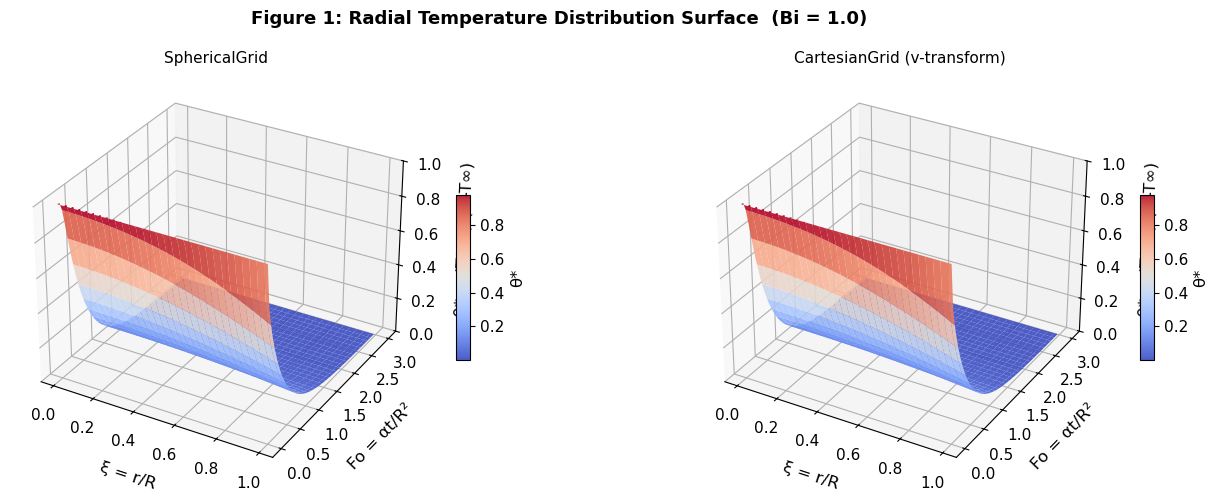

✓ Figure 1 已儲存至: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_03\figs\fig1_surface_comparison.png


In [11]:
# =====================================================================
# Figure 1: 徑向溫度分布時空演變曲面圖 (Case B: Bi=1.0)
# =====================================================================
case_plot = 'Case B (Bi=1.0)'
Bi_plot   = 1.0

if PDE_AVAILABLE and case_plot in results_sph and case_plot in results_cart:
    r_s   = results_sph[case_plot]
    r_c   = results_cart[case_plot]

    fig, axes = plt.subplots(1, 2, subplot_kw={'projection': '3d'},
                             figsize=(14, 5))
    fig.suptitle(f'Figure 1: Radial Temperature Distribution Surface  (Bi = {Bi_plot})',
                 fontsize=13, fontweight='bold')

    for ax, r, method in zip(axes,
                              [r_s, r_c],
                              ['SphericalGrid', 'CartesianGrid (v-transform)']):
        XI, FO = np.meshgrid(r['xi'], r['Fo'])
        surf = ax.plot_surface(XI, FO, r['theta'],
                               cmap='coolwarm', linewidth=0, antialiased=True, alpha=0.9)
        ax.set_xlabel('ξ = r/R', labelpad=8)
        ax.set_ylabel('Fo = αt/R²', labelpad=8)
        ax.set_zlabel('θ* = (T-T∞)/(Ti-T∞)', labelpad=8)
        ax.set_title(method, fontsize=11)
        ax.set_zlim(0, 1)
        fig.colorbar(surf, ax=ax, shrink=0.4, aspect=12, label='θ*')

    plt.tight_layout()
    fig_path = FIG_DIR / 'fig1_surface_comparison.png'
    plt.savefig(fig_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"✓ Figure 1 已儲存至: {fig_path}")
else:
    print("⚠️ py-pde 結果不可用，跳過 Figure 1")

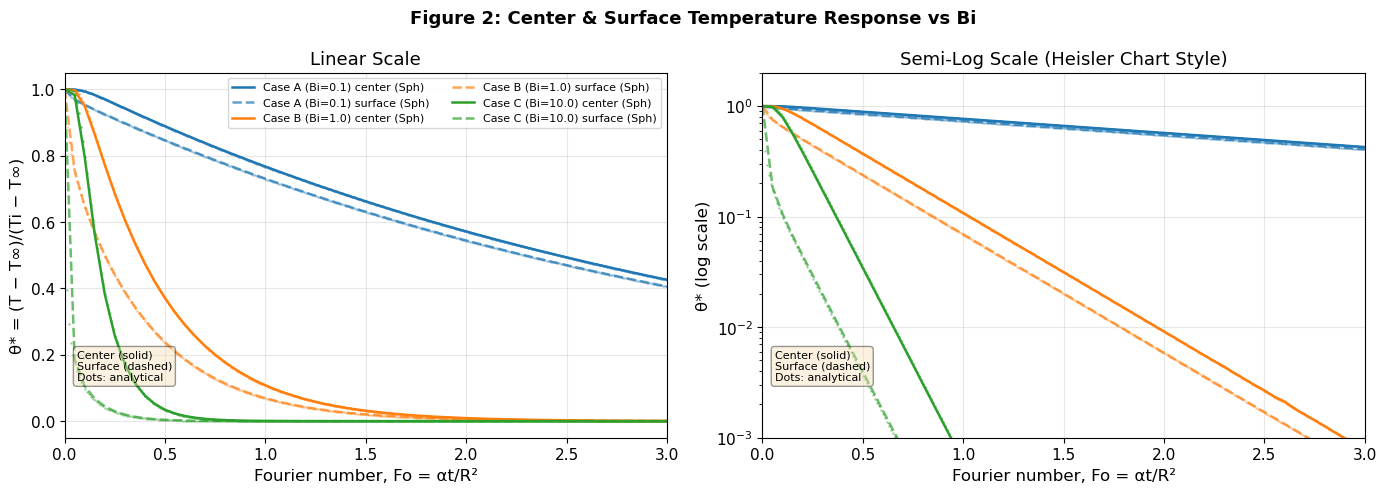

✓ Figure 2 已儲存至: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_03\figs\fig2_center_surface_response.png


In [12]:
# =====================================================================
# Figure 2: 三種 Biot number 下球心與球面無因次溫度時間響應
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 2: Center & Surface Temperature Response vs Bi',
             fontsize=13, fontweight='bold')

colors = {'Case A (Bi=0.1)': 'C0',
          'Case B (Bi=1.0)': 'C1',
          'Case C (Bi=10.0)': 'C2'}
linestyles_center  = '-'
linestyles_surface = '--'

for case_name, Bi in Bi_cases.items():
    c = colors[case_name]

    # 解析解（密集 Fo 數組）
    Fo_ref  = np.linspace(0.01, Fo_max, 300)
    th_ref_center = analytical_sphere([0.0], Fo_ref, Bi, n_eig=80)[:, 0]
    th_ref_surf   = analytical_sphere([1.0], Fo_ref, Bi, n_eig=80)[:, 0]

    # 繪製解析解（點標記）
    for ax in axes:
        ax.plot(Fo_ref, th_ref_center, '.', color=c, markersize=2, alpha=0.5)
        ax.plot(Fo_ref, th_ref_surf,   '.', color=c, markersize=2, alpha=0.3)

    # 數值解（SphericalGrid）
    if PDE_AVAILABLE and case_name in results_sph:
        r = results_sph[case_name]
        Fo_n  = r['Fo']
        th_nc = r['theta'][:, 0]    # 球心
        th_ns = r['theta'][:, -1]   # 球面
        for ax in axes:
            ax.plot(Fo_n, th_nc, color=c, ls=linestyles_center,
                    label=f'{case_name} center (Sph)')
            ax.plot(Fo_n, th_ns, color=c, ls=linestyles_surface, alpha=0.7,
                    label=f'{case_name} surface (Sph)')

# 左圖：線性座標
ax_lin = axes[0]
ax_lin.set_xlabel('Fourier number, Fo = αt/R²')
ax_lin.set_ylabel('θ* = (T − T∞)/(Ti − T∞)')
ax_lin.set_title('Linear Scale')
ax_lin.set_xlim(0, Fo_max)
ax_lin.set_ylim(-0.05, 1.05)
ax_lin.legend(loc='upper right', fontsize=8, ncol=2)

# 右圖：半對數座標，便於驗證單一指數衰減 (Heisler)
ax_log = axes[1]
ax_log.set_yscale('log')
ax_log.set_xlabel('Fourier number, Fo = αt/R²')
ax_log.set_ylabel('θ* (log scale)')
ax_log.set_title('Semi-Log Scale (Heisler Chart Style)')
ax_log.set_xlim(0, Fo_max)
ax_log.set_ylim(1e-3, 2)

# 加上說明文字標籤
for ax in axes:
    ax.text(0.02, 0.15, 'Center (solid)\nSurface (dashed)\nDots: analytical',
            transform=ax.transAxes, fontsize=8, verticalalignment='bottom',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

plt.tight_layout()
fig_path = FIG_DIR / 'fig2_center_surface_response.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"✓ Figure 2 已儲存至: {fig_path}")

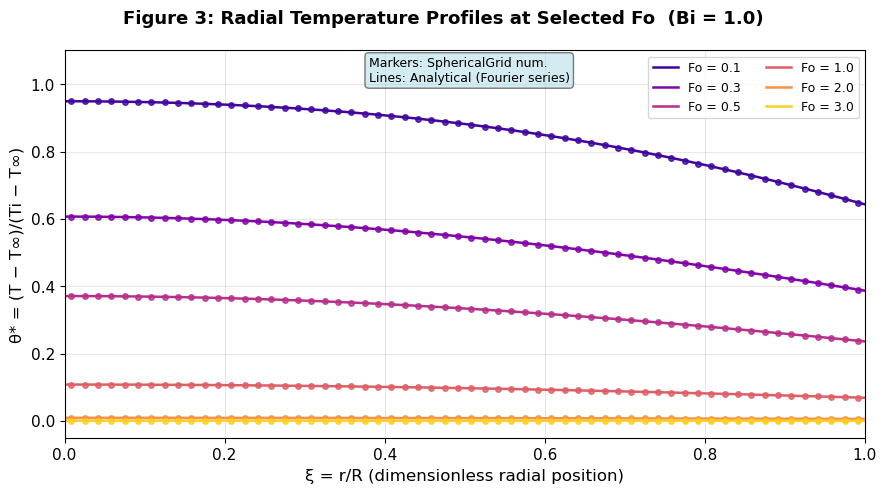

✓ Figure 3 已儲存至: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_03\figs\fig3_radial_profiles.png


In [13]:
# =====================================================================
# Figure 3: 特定 Fourier number 之徑向溫度分布（Case B: Bi=1.0）
# =====================================================================
case_plot = 'Case B (Bi=1.0)'
Bi_plot   = 1.0
Fo_snap   = [0.1, 0.3, 0.5, 1.0, 2.0, 3.0]

if PDE_AVAILABLE and case_plot in results_sph:
    r_s    = results_sph[case_plot]
    xi_num = r_s['xi']
    Fo_num = r_s['Fo']

    # 解析解高分辨率徑向坐標
    xi_ref = np.linspace(0, 1, 200)

    fig, ax = plt.subplots(figsize=(9, 5))
    fig.suptitle(f'Figure 3: Radial Temperature Profiles at Selected Fo  (Bi = {Bi_plot})',
                 fontsize=13, fontweight='bold')

    cmap = plt.cm.plasma
    colors_fo = cmap(np.linspace(0.1, 0.9, len(Fo_snap)))

    for i, Fo_t in enumerate(Fo_snap):
        # 數值解（取最近時間步）
        idx = np.argmin(np.abs(Fo_num - Fo_t))
        th_num = r_s['theta'][idx, :]

        # 解析解
        th_ref = analytical_sphere(xi_ref, np.array([Fo_t]), Bi_plot, n_eig=80)[0, :]

        # 繪製
        ax.plot(xi_num, th_num, 'o', color=colors_fo[i], markersize=4, alpha=0.8)
        ax.plot(xi_ref, th_ref, '-', color=colors_fo[i],
                label=f'Fo = {Fo_t:.1f}')

    ax.set_xlabel('ξ = r/R (dimensionless radial position)')
    ax.set_ylabel('θ* = (T − T∞)/(Ti − T∞)')
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.05, 1.1)
    ax.legend(loc='upper right', ncol=2, fontsize=9)
    ax.text(0.38, 0.92, 'Markers: SphericalGrid num.\nLines: Analytical (Fourier series)',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

    plt.tight_layout()
    fig_path = FIG_DIR / 'fig3_radial_profiles.png'
    plt.savefig(fig_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"✓ Figure 3 已儲存至: {fig_path}")
else:
    print("⚠️ 結果不可用，跳過 Figure 3")

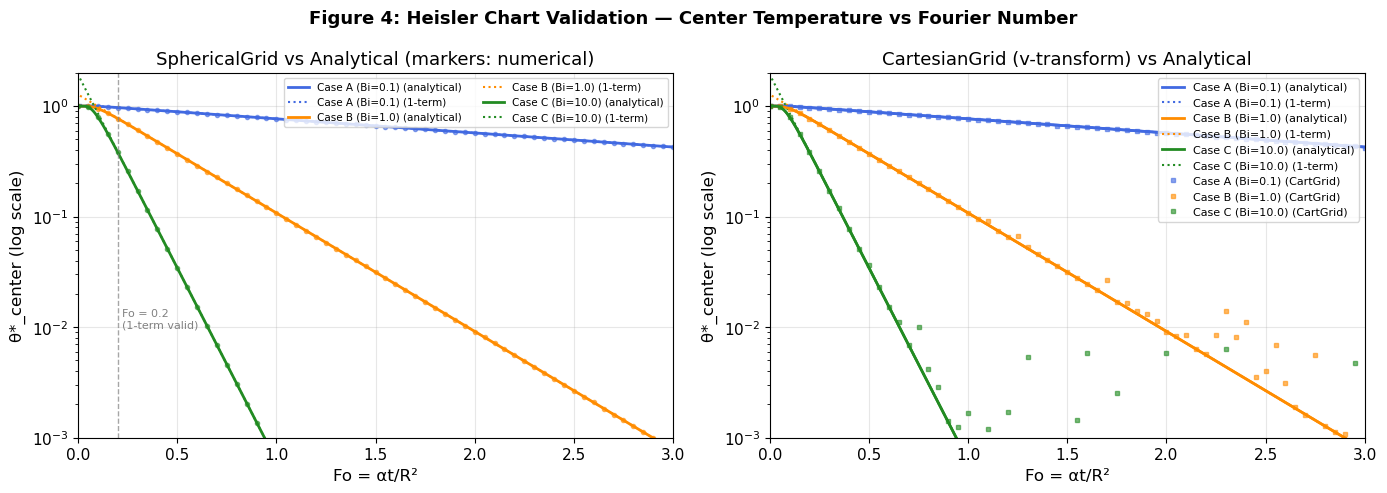

✓ Figure 4 已儲存至: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_03\figs\fig4_heisler_validation.png


In [14]:
# =====================================================================
# Figure 4: Heisler Chart 驗證 — 半對數座標球心溫度衰減（三種 Bi 比較）
# 同時顯示單一指數近似 (one-term) 的有效性
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 4: Heisler Chart Validation — Center Temperature vs Fourier Number',
             fontsize=13, fontweight='bold')

colors_bi = {'Case A (Bi=0.1)': 'royalblue',
             'Case B (Bi=1.0)': 'darkorange',
             'Case C (Bi=10.0)': 'forestgreen'}

Fo_ref = np.linspace(0.01, Fo_max, 400)

for case_name, Bi in Bi_cases.items():
    c = colors_bi[case_name]

    # 精確解析解（50 項）
    th_anal   = analytical_sphere([0.0], Fo_ref, Bi, n_eig=50)[:, 0]
    # 一項近似
    lam1 = get_eigenvalues(Bi, 1)[0]
    C1   = 4 * (np.sin(lam1) - lam1 * np.cos(lam1)) / (2*lam1 - np.sin(2*lam1))
    th_1term  = C1 * np.exp(-lam1**2 * Fo_ref)

    for ax in axes:
        ax.semilogy(Fo_ref, th_anal, '-', color=c, lw=2,
                    label=f'{case_name} (analytical)')
        ax.semilogy(Fo_ref, th_1term, ':', color=c, lw=1.5,
                    label=f'{case_name} (1-term)')

    # 數值解（SphericalGrid）
    if PDE_AVAILABLE and case_name in results_sph:
        r   = results_sph[case_name]
        Fo_n= r['Fo']
        ax_main = axes[0]
        ax_main.semilogy(Fo_n, r['theta'][:, 0], 'o', color=c,
                         markersize=3, alpha=0.6)

# 左圖設定
axes[0].set_xlabel('Fo = αt/R²')
axes[0].set_ylabel('θ*_center (log scale)')
axes[0].set_title('SphericalGrid vs Analytical (markers: numerical)')
axes[0].legend(loc='upper right', fontsize=7.5, ncol=2)
axes[0].set_xlim(0, Fo_max)
axes[0].set_ylim(1e-3, 2)
axes[0].axvline(0.2, color='gray', ls='--', lw=1, alpha=0.7)
axes[0].text(0.22, 0.3, 'Fo = 0.2\n(1-term valid)', fontsize=8, color='gray',
             transform=axes[0].get_xaxis_transform())

# 右圖：CartesianGrid vs Analytical
for case_name, Bi in Bi_cases.items():
    c = colors_bi[case_name]
    if PDE_AVAILABLE and case_name in results_cart:
        r    = results_cart[case_name]
        Fo_n = r['Fo']
        axes[1].semilogy(Fo_n, r['theta'][:, 0], 's', color=c,
                         markersize=3, alpha=0.6,
                         label=f'{case_name} (CartGrid)')
    th_a = analytical_sphere([0.0], np.linspace(0.01, Fo_max, 400), Bi, n_eig=50)[:, 0]
    axes[1].semilogy(np.linspace(0.01, Fo_max, 400), th_a, '-', color=c)

axes[1].set_xlabel('Fo = αt/R²')
axes[1].set_ylabel('θ*_center (log scale)')
axes[1].set_title('CartesianGrid (v-transform) vs Analytical')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].set_xlim(0, Fo_max)
axes[1].set_ylim(1e-3, 2)

plt.tight_layout()
fig_path = FIG_DIR / 'fig4_heisler_validation.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"✓ Figure 4 已儲存至: {fig_path}")

---
### 8. 學習總結

**關鍵學習重點：**

1. **球座標算子的幾何意義：** 球座標熱傳方程式中 $\frac{2}{r}\frac{\partial T}{\partial r}$ 項代表球殼面積隨半徑增大而擴張的效應（幾何因子），數值求解時 $r = 0$ 存在奇異性。

2. **變數代換 $v = r(T-T_\infty)$ ：** 此技巧將球座標 PDE 轉換為標準一維笛卡兒熱傳方程式，消除奇異性，邊界條件也從 Neumann（對稱）轉為 Dirichlet（ $v=0$ ），從 Robin 轉為修正 Robin 形式。

3. **Biot number 的物理意義：**
   - $Bi \ll 1$ （Case A）：球體溫度近乎均勻，Lumped 模型適用， $\theta^* \approx e^{-3Bi\cdot Fo}$
   - $Bi \sim 1$ （Case B）：兩種阻力相當，需完整 PDE 求解
   - $Bi \gg 1$ （Case C）：表面等溫化，傳導為主要熱阻，球體冷卻速率最快，中心溫度衰減較 Case A 更迅速

4. **Heisler Chart 有效域：** 當 $Fo > 0.2$ 後，一項指數近似足夠精確（高階模態衰減完畢），這是 Heisler chart 的應用前提。

5. **py-pde SphericalSymGrid vs CartesianGrid（v 代換）：** 兩種方法精度相當，SphericalSymGrid 更直觀，CartesianGrid 方法則揭示了球座標問題的數學結構。

---

**課程資訊**
- 課程名稱：電腦在化工上之應用 (ChemE 3502)
- 課程單元：Unit10 偏微分方程式之求解 - 範例 03
- 課程製作：逢甲大學 化工系 智慧程序系統工程實驗室
- 授課教師：莊曜禎 助理教授
- 更新日期：2026-02-23

**課程授權 [CC BY-NC-SA 4.0]**
 - 本教材遵循 [創用CC 姓名標示-非商業性-相同方式分享 4.0 國際 (CC BY-NC-SA 4.0)](https://creativecommons.org/licenses/by-nc-sa/4.0/deed.zh) 授權。
